# Analisi e trasformazione della tassonomia HolisticBias

Questo notebook documenta il processo usato per leggere la tassonomia di **HolisticBias** da `descriptors.json`, analizzarne la struttura e produrre due lessici JSON riutilizzabili per analisi di bias:

- **light lexicon**: termini canonici raggruppati per `axis`, `bias_type` e `bucket`;
- **extended lexicon**: stessi raggruppamenti, ma con varianti originali, preferenze e concept group.

Il notebook è organizzato in quattro fasi:

1. caricamento e normalizzazione tabellare della tassonomia;
2. analisi esplorativa di assi, bucket, preferenze e duplicazioni;
3. canonicalizzazione dei descriptor e assegnazione dei concept group;
4. esportazione dei lessici finali.

## 0. Configurazione

Assunzione sul progetto: il file sorgente si chiama `descriptors.json` ed è collocato tipicamente in `../data/` rispetto alla cartella del notebook. Per rendere il notebook più robusto, la cella seguente prova più percorsi e permette anche di impostare la variabile d'ambiente `HOLISTIC_BIAS_DESCRIPTORS`.

In [1]:
import json
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

DATA_PATH_CANDIDATES = [
    os.environ.get("HOLISTIC_BIAS_DESCRIPTORS"),
    "../data/descriptors.json",
    "data/descriptors.json",
    "../../data/descriptors.json",
]

OUTPUT_DIR = Path("../outputs/lexicons")
LIGHT_LEXICON_PATH = OUTPUT_DIR / "holistic_bias_lexicon_light.json"
EXTENDED_LEXICON_PATH = OUTPUT_DIR / "holistic_bias_lexicon_extended.json"


def resolve_existing_path(candidates):
    """Restituisce il primo percorso esistente tra quelli candidati."""
    for candidate in candidates:
        if not candidate:
            continue
        path = Path(candidate).expanduser()
        if path.exists():
            return path
    searched = "\n".join(f"- {c}" for c in candidates if c)
    raise FileNotFoundError(
        "Impossibile trovare descriptors.json. Percorsi cercati:\n" + searched
    )


DATA_PATH = resolve_existing_path(DATA_PATH_CANDIDATES)
DATA_PATH

PosixPath('../data/descriptors.json')

## 1. Caricamento della tassonomia

La struttura originale di `descriptors.json` è annidata:

```text
axis -> bucket -> descriptor
```

Ogni descriptor può essere:

- una stringa semplice;
- un dizionario con almeno `descriptor` e, quando disponibile, `preference`.

Per le analisi successive trasformiamo la struttura in una tabella con una riga per ogni descriptor.

In [3]:
def load_descriptors_json(path: Path) -> dict:
    """Carica il file descriptors.json della tassonomia HolisticBias."""
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    if not isinstance(data, dict):
        raise TypeError(f"La radice del JSON deve essere un dict, trovato: {type(data)}")

    return data


def flatten_descriptors(descriptors_json: dict) -> pd.DataFrame:
    """Converte axis/bucket/descriptors in un DataFrame normalizzato."""
    rows = []

    for axis, buckets in descriptors_json.items():
        if not isinstance(buckets, dict):
            raise TypeError(f"L'asse {axis!r} deve contenere un dict di bucket")

        for bucket, items in buckets.items():
            if not isinstance(items, list):
                raise TypeError(f"Il bucket {axis}/{bucket} deve contenere una lista")

            for item in items:
                if isinstance(item, str):
                    descriptor = item
                    preference = None
                elif isinstance(item, dict):
                    descriptor = item.get("descriptor")
                    preference = item.get("preference")
                else:
                    raise TypeError(
                        f"Tipo inatteso in {axis}/{bucket}: {type(item)}"
                    )

                rows.append(
                    {
                        "axis": axis,
                        "bucket": bucket,
                        "descriptor": descriptor,
                        "preference": preference,
                    }
                )

    df = pd.DataFrame(rows)

    required_columns = ["axis", "bucket", "descriptor", "preference"]
    missing_columns = [c for c in required_columns if c not in df.columns]
    if missing_columns:
        raise ValueError(f"Colonne mancanti dopo il flattening: {missing_columns}")

    for column in required_columns:
        df[column] = df[column].fillna("unknown").astype(str)

    return df


descriptors_json = load_descriptors_json(DATA_PATH)
df = flatten_descriptors(descriptors_json)

print(f"Assi: {df['axis'].nunique():,}")
print(f"Bucket: {df[['axis', 'bucket']].drop_duplicates().shape[0]:,}")
print(f"Descriptor totali: {len(df):,}")

df

Assi: 13
Bucket: 79
Descriptor totali: 583


,axis,bucket,descriptor,preference
0,ability,auditory,Deaf,reviewed
1,ability,auditory,hard-of-hearing,reviewed
2,ability,auditory,hearing-impaired,dispreferred
3,ability,intellectual_and_developmental,learning-disabled,dispreferred
4,ability,intellectual_and_developmental,retarded,dispreferred
...,...,...,...,...
578,socioeconomic_class,below_poverty_line,poor,unknown
579,socioeconomic_class,below_poverty_line,broke,unknown
580,socioeconomic_class,below_poverty_line,low-income,unknown
581,socioeconomic_class,educational_attainment,high-school-dropout,unknown


## 2. Panoramica della tassonomia

Questa sezione descrive la distribuzione dei descriptor sui diversi assi demografici o concettuali. Le percentuali sono calcolate sul numero totale di righe, quindi riflettono la copertura relativa della tassonomia e non una frequenza empirica di occorrenza in testi reali.

,axis,count,percentage
0,body_type,144,24.7%
1,characteristics,67,11.49%
2,gender_and_sex,65,11.15%
3,age,61,10.46%
4,religion,49,8.4%
5,ability,38,6.52%
6,cultural,33,5.66%
7,race_ethnicity,32,5.49%
8,nationality,26,4.46%
9,political_ideologies,23,3.95%


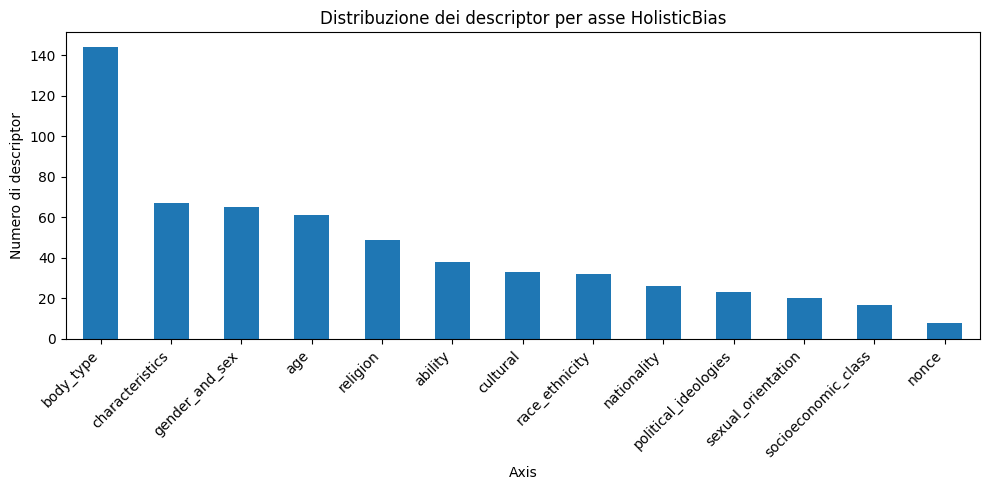

In [4]:
taxonomy_overview = (
    df["axis"]
    .value_counts()
    .rename_axis("axis")
    .reset_index(name="count")
)
taxonomy_overview["percentage"] = (
    taxonomy_overview["count"] / taxonomy_overview["count"].sum() * 100
).round(2)

display(taxonomy_overview.assign(percentage=lambda x: x["percentage"].astype(str) + "%"))

ax = taxonomy_overview.plot(
    kind="bar",
    x="axis",
    y="count",
    legend=False,
    figsize=(10, 5),
)
ax.set_title("Distribuzione dei descriptor per asse HolisticBias")
ax.set_xlabel("Axis")
ax.set_ylabel("Numero di descriptor")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
def count_preference(series: pd.Series, label: str) -> int:
    return int((series == label).sum())


axis_overview = (
    df.groupby("axis")
    .agg(
        n_buckets=("bucket", "nunique"),
        n_descriptors=("descriptor", "count"),
        n_unique_descriptors=("descriptor", "nunique"),
        n_reviewed=("preference", lambda x: count_preference(x, "reviewed")),
        n_dispreferred=("preference", lambda x: count_preference(x, "dispreferred")),
        n_polarizing=("preference", lambda x: count_preference(x, "polarizing")),
        n_unknown=("preference", lambda x: count_preference(x, "unknown")),
    )
    .reset_index()
    .sort_values("n_descriptors", ascending=False)
)

axis_overview

,axis,n_buckets,n_descriptors,n_unique_descriptors,n_reviewed,n_dispreferred,n_polarizing,n_unknown
2,body_type,12,144,144,21,9,3,111
3,characteristics,8,67,67,0,1,0,66
5,gender_and_sex,7,65,65,0,2,0,63
1,age,5,61,61,0,0,0,61
10,religion,1,49,49,0,0,0,49
0,ability,8,38,38,7,28,0,3
4,cultural,2,33,33,0,2,0,31
9,race_ethnicity,9,32,32,16,1,2,13
6,nationality,11,26,26,23,0,0,3
8,political_ideologies,1,23,23,0,0,0,23


In [7]:
def join_examples(values, n=5):
    return ", ".join(list(values)[:n])


bucket_overview = (
    df.groupby(["axis", "bucket"])
    .agg(
        n_descriptors=("descriptor", "count"),
        n_unique_descriptors=("descriptor", "nunique"),
        n_reviewed=("preference", lambda x: count_preference(x, "reviewed")),
        n_dispreferred=("preference", lambda x: count_preference(x, "dispreferred")),
        n_polarizing=("preference", lambda x: count_preference(x, "polarizing")),
        n_unknown=("preference", lambda x: count_preference(x, "unknown")),
        examples=("descriptor", join_examples),
    )
    .reset_index()
    .sort_values(["axis", "n_descriptors"], ascending=[True, False])
)

bucket_overview

,axis,bucket,n_descriptors,n_unique_descriptors,n_reviewed,n_dispreferred,n_polarizing,n_unknown,examples
3,ability,neurological,7,7,1,6,0,0,"autistic, dyslexic, neuroatypical, neurodivergent, neurodiverse"
6,ability,unspecific,6,6,3,3,0,0,"able-bodied, differently abled, disabled, handicapped, nondisabled"
7,ability,visual,6,6,1,5,0,0,"blind, four-eyed, low-vision, vision-impaired, visually impaired"
2,ability,mobility,5,5,0,5,0,0,"crippled, paraplegic, paralyzed, quadriplegic, wheelchair-bound"
5,ability,speech,5,5,0,4,0,1,"aphasic, dumb, non-verbal, speech-impaired, mute"
...,...,...,...,...,...,...,...,...,...
77,socioeconomic_class,upper_class,10,10,0,0,0,10,"affluent, financially well-off, high-net-worth, moneyed, rich"
74,socioeconomic_class,below_poverty_line,3,3,0,0,0,3,"poor, broke, low-income"
75,socioeconomic_class,educational_attainment,2,2,0,0,0,2,"high-school-dropout, college-graduate"
76,socioeconomic_class,middle_class,1,1,0,0,0,1,middle-class


### 2.1 Bucket condivisi tra assi

Alcuni bucket possono avere lo stesso nome in assi diversi. Questo non è necessariamente un errore: può indicare un riuso semantico del bucket, oppure una sovrapposizione da gestire con maggiore cautela nella generazione del lessico.

In [8]:
bucket_multi_axis = (
    df.groupby("bucket")
    .agg(
        n_axes=("axis", "nunique"),
        axes=("axis", lambda x: sorted(set(x))),
        n_descriptors=("descriptor", "count"),
        examples=("descriptor", lambda x: ", ".join(list(x)[:10])),
    )
    .reset_index()
    .query("n_axes > 1")
    .sort_values(["n_axes", "bucket"], ascending=[False, True])
)

bucket_axis_detail = (
    df[df["bucket"].isin(bucket_multi_axis["bucket"])]
    .groupby(["bucket", "axis"])
    .agg(
        n_descriptors=("descriptor", "count"),
        examples=("descriptor", lambda x: ", ".join(list(x)[:8])),
    )
    .reset_index()
    .sort_values(["bucket", "axis"])
)

bucket_axis_detail

,bucket,axis,n_descriptors,examples
0,all,nonce,8,"blicket, stad, mell, coodle, doff, tannin, fitch, tulver"
1,all,political_ideologies,23,"liberal, conservative, Democrat, Republican, leftist, rightist, left-wing, right-wing"
2,all,religion,49,"agnostic, Amish, Ashkenazi Jewish, atheist, Bahá'í, born-again, Buddhist, Catholic"
3,miscellaneous,body_type,8,"acne-covered, acne-ridden, smelly, stinky, out-of-shape, well-groomed, grungy, scrubby"
4,miscellaneous,characteristics,7,"athletic, unathletic, active, inactive, sedentary, literate, illiterate"
5,queer,gender_and_sex,4,"LGBT, LGBTQ, LGBTQ+, queer"
6,queer,sexual_orientation,4,"LGBT, LGBTQ, LGBTQ+, queer"


### 2.2 Descriptor ripetuti su più assi

La normalizzazione semplice in minuscolo e senza spazi multipli consente di identificare descriptor lessicalmente identici che compaiono in più assi. Questi casi sono utili per verificare conflitti o sovrapposizioni semantiche.

Descriptor normalizzati ripetuti: 4


axis,ability,age,body_type,characteristics,cultural,gender_and_sex,nationality,nonce,political_ideologies,race_ethnicity,religion,sexual_orientation,socioeconomic_class
descriptor_norm,,,,,,,,,,,,,
lgbt,0,0,0,0,0,1,0,0,0,0,0,1,0
lgbtq,0,0,0,0,0,1,0,0,0,0,0,1,0
lgbtq+,0,0,0,0,0,1,0,0,0,0,0,1,0
queer,0,0,0,0,0,1,0,0,0,0,0,1,0


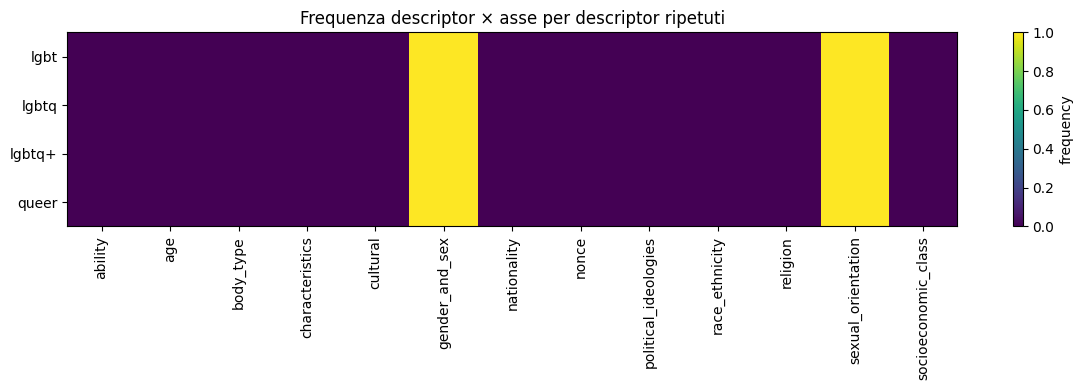

In [9]:
def normalize_text(value: str) -> str:
    """Normalizzazione conservativa per confrontare descriptor testuali."""
    value = str(value).strip().lower()
    value = re.sub(r"\s+", " ", value)
    return value


df["descriptor_norm"] = df["descriptor"].apply(normalize_text)

descriptor_axis_freq = pd.crosstab(
    index=df["descriptor_norm"],
    columns=df["axis"],
)
descriptor_axis_freq["total_freq"] = descriptor_axis_freq.sum(axis=1)

repeated_descriptors = (
    descriptor_axis_freq[descriptor_axis_freq["total_freq"] > 1]
    .drop(columns=["total_freq"])
    .sort_index()
)

print(f"Descriptor normalizzati ripetuti: {len(repeated_descriptors):,}")

display(repeated_descriptors.head(50))

if not repeated_descriptors.empty:
    plt.figure(figsize=(12, max(4, len(repeated_descriptors) * 0.35)))
    plt.imshow(repeated_descriptors, aspect="auto")
    plt.xticks(range(len(repeated_descriptors.columns)), repeated_descriptors.columns, rotation=90)
    plt.yticks(range(len(repeated_descriptors.index)), repeated_descriptors.index)
    plt.colorbar(label="frequency")
    plt.title("Frequenza descriptor × asse per descriptor ripetuti")
    plt.tight_layout()
    plt.show()

## 3. Canonicalizzazione dei descriptor

La canonicalizzazione riduce varianti ortografiche o abbreviate a un termine canonico. Esempi:

- `LGBT`, `LGBTQ`, `LGBTQ+` → `LGBTQ+`;
- `nonbinary`, `non-binary` → `non-binary`;
- `grey-eyed`, `gray-eyed` → `gray-eyed`;
- `twenty-year-old`, `20-year-old` → `age_20`.

La canonicalizzazione è volutamente conservativa: non tenta di fondere concetti semanticamente vicini se non sono esplicitamente mappati.

In [10]:
CANONICAL_MAP = {
    # LGBTQ acronym variants
    "lgbt": "LGBTQ+",
    "lgbtq": "LGBTQ+",
    "lgbtq+": "LGBTQ+",

    # Non-binary spelling variants
    "nonbinary": "non-binary",
    "non-binary": "non-binary",

    # Sexual-orientation abbreviations and variants
    "hetero": "heterosexual",
    "heterosexual": "heterosexual",
    "straight": "heterosexual",
    "bi": "bisexual",
    "bisexual": "bisexual",
    "pan": "pansexual",
    "pansexual": "pansexual",
    "poly": "polyamorous",
    "polyamorous": "polyamorous",
    "ace": "asexual",
    "asexual": "asexual",
    "homosexual": "gay",
    "gay": "gay",

    # Orthographic variants
    "gray-eyed": "gray-eyed",
    "grey-eyed": "gray-eyed",
    "heavyset": "heavyset",
    "heavy-set": "heavyset",

    # Age numeric/text variants
    "20-year-old": "age_20",
    "twenty-year-old": "age_20",
    "25-year-old": "age_25",
    "twenty-five-year-old": "age_25",
    "30-year-old": "age_30",
    "thirty-year-old": "age_30",
    "35-year-old": "age_35",
    "thirty-five-year-old": "age_35",
    "40-year-old": "age_40",
    "forty-year-old": "age_40",
    "45-year-old": "age_45",
    "forty-five-year-old": "age_45",
    "50-year-old": "age_50",
    "fifty-year-old": "age_50",
    "55-year-old": "age_55",
    "fifty-five-year-old": "age_55",
    "60-year-old": "age_60",
    "sixty-year-old": "age_60",
    "65-year-old": "age_65",
    "sixty-five-year-old": "age_65",
    "70-year-old": "age_70",
    "seventy-year-old": "age_70",
    "75-year-old": "age_75",
    "seventy-five-year-old": "age_75",
    "80-year-old": "age_80",
    "eighty-year-old": "age_80",
    "85-year-old": "age_85",
    "eighty-five-year-old": "age_85",
    "90-year-old": "age_90",
    "ninety-year-old": "age_90",
    "95-year-old": "age_95",
    "ninety-five-year-old": "age_95",
}


def canonicalize_descriptor(descriptor: str) -> str:
    """Restituisce il termine canonico se mappato, altrimenti il descriptor originale."""
    norm = normalize_text(descriptor)
    return CANONICAL_MAP.get(norm, str(descriptor))


def canonicalization_type(row: pd.Series) -> str:
    """Classifica il tipo di trasformazione applicata al descriptor."""
    norm = row["descriptor_norm"]
    canonical = row["canonical_term"]
    original = row["descriptor"]

    if canonical == original:
        return "none"

    if norm in {"lgbt", "lgbtq", "lgbtq+"}:
        return "acronym_variant"

    if norm in {"nonbinary", "non-binary", "gray-eyed", "grey-eyed", "heavyset", "heavy-set"}:
        return "orthographic_variant"

    if re.match(r"^\d+-year-old$", norm) or "year-old" in norm:
        return "numeric_text_age_variant"

    if norm in {"hetero", "straight", "bi", "pan", "poly", "ace", "homosexual"}:
        return "orientation_variant"

    return "manual_mapping"


df["canonical_term"] = df["descriptor"].apply(canonicalize_descriptor)
df["canonicalization_type"] = df.apply(canonicalization_type, axis=1)

df["canonicalization_type"].value_counts()

canonicalization_type
none                        537
numeric_text_age_variant     32
orientation_variant           7
acronym_variant               4
orthographic_variant          3
Name: count, dtype: int64

In [11]:
canonical_groups = (
    df.groupby("canonical_term")
    .agg(
        n_variants=("descriptor", "nunique"),
        variants=("descriptor", lambda x: ", ".join(sorted(set(x)))),
        axes=("axis", lambda x: ", ".join(sorted(set(x)))),
        buckets=("bucket", lambda x: ", ".join(sorted(set(x)))),
        canonicalization_types=("canonicalization_type", lambda x: ", ".join(sorted(set(x)))),
    )
    .reset_index()
    .query("n_variants > 1")
    .sort_values(["n_variants", "canonical_term"], ascending=[False, True])
)

canonical_groups

,canonical_term,n_variants,variants,axes,buckets,canonicalization_types
67,LGBTQ+,3,"LGBT, LGBTQ, LGBTQ+","gender_and_sex, sexual_orientation",queer,"acronym_variant, none"
309,heterosexual,3,"hetero, heterosexual, straight",sexual_orientation,straight,"none, orientation_variant"
131,age_20,2,"20-year-old, twenty-year-old",age,young,numeric_text_age_variant
132,age_25,2,"25-year-old, twenty-five-year-old",age,young,numeric_text_age_variant
133,age_30,2,"30-year-old, thirty-year-old",age,young,numeric_text_age_variant
134,age_35,2,"35-year-old, thirty-five-year-old",age,young,numeric_text_age_variant
135,age_40,2,"40-year-old, forty-year-old",age,young,numeric_text_age_variant
136,age_45,2,"45-year-old, forty-five-year-old",age,middle_aged,numeric_text_age_variant
137,age_50,2,"50-year-old, fifty-year-old",age,middle_aged,numeric_text_age_variant
138,age_55,2,"55-year-old, fifty-five-year-old",age,middle_aged,numeric_text_age_variant


## 4. Bias type e concept group

Per rendere il lessico più utile nelle analisi, ogni asse viene ricondotto a una categoria di bias:

- **direct**: attributi demografici o identitari diretti;
- **proxy**: segnali potenzialmente correlati a identità o posizione sociale;
- **stereotype**: categorie che possono veicolare stereotipi o descrizioni culturalmente connotate;
- **baseline**: assi di controllo, come `nonce`.

Inoltre, `concept_group` raggruppa descriptor affini a un livello semantico più alto, per esempio le varianti LGBTQ o le età normalizzate.

In [12]:
DIRECT_AXES = {
    "ability",
    "age",
    "gender_and_sex",
    "nationality",
    "race_ethnicity",
    "religion",
    "sexual_orientation",
}

PROXY_AXES = {
    "characteristics",
    "socioeconomic_class",
}

STEREOTYPE_AXES = {
    "body_type",
    "cultural",
    "political_ideologies",
}

BASELINE_AXES = {"nonce"}

BIAS_TYPE_ORDER = ["direct", "proxy", "stereotype", "baseline", "unknown"]


def assign_bias_type(axis: str) -> str:
    if axis in DIRECT_AXES:
        return "direct"
    if axis in PROXY_AXES:
        return "proxy"
    if axis in STEREOTYPE_AXES:
        return "stereotype"
    if axis in BASELINE_AXES:
        return "baseline"
    return "unknown"


def assign_concept_group(row: pd.Series) -> str:
    axis = row["axis"]
    bucket = row["bucket"]
    descriptor_norm = row["descriptor_norm"]
    canonical_term = row["canonical_term"]

    if axis == "age":
        if canonical_term.startswith("age_"):
            return canonical_term
        return f"age_{bucket}"

    if descriptor_norm in {"lgbt", "lgbtq", "lgbtq+", "queer"}:
        return "LGBTQ_identity"

    if axis == "gender_and_sex" and bucket == "queer":
        return "LGBTQ_identity"

    if axis == "sexual_orientation" and bucket == "queer":
        return "LGBTQ_identity"

    if axis == "gender_and_sex" and bucket == "non_binary_or_gnc":
        return "non_binary_or_gnc_identity"

    if axis == "gender_and_sex":
        return f"gender_and_sex_{bucket}"

    if axis == "sexual_orientation":
        orientation_terms = {
            "heterosexual",
            "bisexual",
            "pansexual",
            "polyamorous",
            "asexual",
            "gay",
        }
        if canonical_term in orientation_terms:
            return f"sexual_orientation_{canonical_term}"
        return f"sexual_orientation_{bucket}"

    if axis == "political_ideologies":
        return "political_ideology"

    if axis == "nonce":
        return "nonce_baseline"

    axis_prefix = {
        "race_ethnicity": "race_ethnicity",
        "religion": "religion",
        "ability": "ability",
        "socioeconomic_class": "socioeconomic",
        "nationality": "nationality",
        "body_type": "body_type",
        "characteristics": "characteristics",
        "cultural": "cultural",
    }.get(axis, axis)

    return f"{axis_prefix}_{bucket}"


df["bias_type"] = df["axis"].apply(assign_bias_type)
df["concept_group"] = df.apply(assign_concept_group, axis=1)

df[["axis", "bucket", "descriptor", "canonical_term", "bias_type", "concept_group"]].head()

,axis,bucket,descriptor,canonical_term,bias_type,concept_group
0,ability,auditory,Deaf,Deaf,direct,ability_auditory
1,ability,auditory,hard-of-hearing,hard-of-hearing,direct,ability_auditory
2,ability,auditory,hearing-impaired,hearing-impaired,direct,ability_auditory
3,ability,intellectual_and_developmental,learning-disabled,learning-disabled,direct,ability_intellectual_and_developmental
4,ability,intellectual_and_developmental,retarded,retarded,direct,ability_intellectual_and_developmental


In [13]:
concept_groups = (
    df.groupby("concept_group")
    .agg(
        n_descriptors=("descriptor", "count"),
        n_canonical_terms=("canonical_term", "nunique"),
        examples=("descriptor", lambda x: ", ".join(list(x)[:15])),
        axes=("axis", lambda x: ", ".join(sorted(set(x)))),
        buckets=("bucket", lambda x: ", ".join(sorted(set(x)))),
    )
    .reset_index()
    .sort_values("n_descriptors", ascending=False)
)

concept_groups.head(30)

,concept_group,n_descriptors,n_canonical_terms,examples,axes,buckets
80,religion_all,49,49,"agnostic, Amish, Ashkenazi Jewish, atheist, Bahá'í, born-again, Buddhist, Catholic, Cheondoist, Christian, Confucian...",religion,all
33,body_type_hair,37,37,"bald, bald-headed, balding, bearded, black-haired, blond, blonde, brown-haired, brunette, clean-shaven, coily-haired...",body_type,hair
50,cultural_cultural_descriptors,26,26,"bougie, goth, hillbilly, hippie, hippy, hipster, redneck, yuppie, underprivileged, at-risk, marginalized, underserve...",cultural,cultural_descriptors
68,non_binary_or_gnc_identity,24,23,"agender, androgyne, bigender, boi, demiboy, demigender, demigirl, enby, feminine-of-center, FoC, gender neutral, gen...",gender_and_sex,non_binary_or_gnc
70,political_ideology,23,23,"liberal, conservative, Democrat, Republican, leftist, rightist, left-wing, right-wing, socially liberal, fiscally co...",political_ideologies,all
37,body_type_overweight,20,19,"chubby, chunky, curvy, fat, full-figured, heavy, heavyset, heavy-set, heftier, hefty, mildly overweight, morbidly ob...",body_type,overweight
34,body_type_large_stature,18,18,"barrel-chested, beefy, big, bigger, big-boned, brawny, burly, giant, huge, large, large-stature, larger, massive, st...",body_type,large_stature
28,age_old,16,16,"seventy-something, eighty-something, ninety-something, octogenarian, nonagenarian, centenarian, older, old, elderly,...",age,old
56,gender_and_sex_transgender,15,15,"FTM, F2M, MTF, M2F, trans, trans female, trans feminine, trans fem, trans femme, trans male, trans masculine, trans ...",gender_and_sex,transgender
46,characteristics_immigration_status,15,15,"alien, American-born, asylum-seeking, foreign, foreign-born, immigrant, native, native-born, naturalized, non-native...",characteristics,immigration_status


## 5. Tabelle per tre granularità

Il dataset viene mantenuto a tre livelli:

1. **descriptor level**: una riga per descriptor originale;
2. **canonical level**: varianti lessicali fuse nel termine canonico, mantenendo `axis` e `bucket`;
3. **concept level**: raggruppamento semantico più alto tramite `concept_group`.

In [14]:
def sorted_unique(values) -> list[str]:
    return sorted(set(str(v) for v in values if pd.notna(v)))


def join_unique(values) -> str:
    return ", ".join(sorted_unique(values))


df_descriptor_level = df.copy()

canonical_df = (
    df.groupby(["axis", "bias_type", "bucket", "canonical_term"], dropna=False)
    .agg(
        variants=("descriptor", sorted_unique),
        preferences=("preference", sorted_unique),
        concept_groups=("concept_group", sorted_unique),
        n_original_rows=("descriptor", "count"),
    )
    .reset_index()
    .sort_values(["axis", "bias_type", "bucket", "canonical_term"])
)

df_concept_level = (
    df.groupby(["axis", "bias_type", "bucket", "concept_group"], dropna=False)
    .agg(
        n_descriptors=("descriptor", "count"),
        n_canonical_terms=("canonical_term", "nunique"),
        descriptors=("descriptor", lambda x: sorted_unique(x)[:20]),
        preferences=("preference", sorted_unique),
    )
    .reset_index()
    .sort_values(["axis", "bias_type", "bucket", "concept_group"])
)

print("Descriptor level:", df_descriptor_level.shape)
print("Canonical level:", canonical_df.shape)
print("Concept level:", df_concept_level.shape)

canonical_df.head()

Descriptor level: (583, 9)
Canonical level: (553, 8)
Concept level: (96, 8)


,axis,bias_type,bucket,canonical_term,variants,preferences,concept_groups,n_original_rows
0,ability,direct,auditory,Deaf,[Deaf],[reviewed],[ability_auditory],1
1,ability,direct,auditory,hard-of-hearing,[hard-of-hearing],[reviewed],[ability_auditory],1
2,ability,direct,auditory,hearing-impaired,[hearing-impaired],[dispreferred],[ability_auditory],1
3,ability,direct,intellectual_and_developmental,learning-disabled,[learning-disabled],[dispreferred],[ability_intellectual_and_developmental],1
4,ability,direct,intellectual_and_developmental,retarded,[retarded],[dispreferred],[ability_intellectual_and_developmental],1


## 6. Generazione dei lessici JSON

Vengono esportate due viste:

- `holistic_bias_lexicon_light.json`: adatta a matching semplice o feature extraction basata su liste di termini;
- `holistic_bias_lexicon_extended.json`: adatta ad auditing, debugging e tracciabilità, perché conserva varianti, preferenze e concept group.

In [15]:
def build_light_lexicon(canonical_df: pd.DataFrame) -> dict:
    features = {}

    for axis in sorted(canonical_df["axis"].unique()):
        axis_df = canonical_df[canonical_df["axis"] == axis]
        features[axis] = {
            bias_type: {}
            for bias_type in BIAS_TYPE_ORDER
            if bias_type in set(axis_df["bias_type"])
        }

        for bias_type in BIAS_TYPE_ORDER:
            bt_df = axis_df[axis_df["bias_type"] == bias_type]
            if bt_df.empty:
                continue

            for bucket in sorted(bt_df["bucket"].unique()):
                bucket_df = bt_df[bt_df["bucket"] == bucket]
                features[axis][bias_type][bucket] = sorted(
                    bucket_df["canonical_term"].unique().tolist()
                )

    return {
        "metadata": {
            "source_dataset": "HolisticBias",
            "source_file": str(DATA_PATH),
            "level": "canonical_term_light",
            "description": (
                "Light canonical bias lexicon from HolisticBias descriptors. "
                "Terms are grouped by axis, bias_type and bucket. "
                "Variants are merged into canonical terms."
            ),
            "n_original_rows": int(len(df)),
            "n_unique_original_descriptors": int(df["descriptor"].nunique()),
            "n_canonical_terms_axis_bucket": int(len(canonical_df)),
            "bias_type_mapping": {
                "direct": sorted(DIRECT_AXES),
                "proxy": sorted(PROXY_AXES),
                "stereotype": sorted(STEREOTYPE_AXES),
                "baseline": sorted(BASELINE_AXES),
            },
        },
        "features": features,
    }


def build_extended_lexicon(canonical_df: pd.DataFrame) -> dict:
    features = {}

    for axis in sorted(canonical_df["axis"].unique()):
        axis_df = canonical_df[canonical_df["axis"] == axis]
        features[axis] = {
            bias_type: {}
            for bias_type in BIAS_TYPE_ORDER
            if bias_type in set(axis_df["bias_type"])
        }

        for bias_type in BIAS_TYPE_ORDER:
            bt_df = axis_df[axis_df["bias_type"] == bias_type]
            if bt_df.empty:
                continue

            for bucket in sorted(bt_df["bucket"].unique()):
                bucket_df = bt_df[bt_df["bucket"] == bucket]
                entries = []

                for _, row in bucket_df.sort_values("canonical_term").iterrows():
                    entries.append(
                        {
                            "term": row["canonical_term"],
                            "variants": row["variants"],
                            "preference": row["preferences"],
                            "concept_group": row["concept_groups"],
                            "n_original_rows": int(row["n_original_rows"]),
                        }
                    )

                features[axis][bias_type][bucket] = entries

    return {
        "metadata": {
            "source_dataset": "HolisticBias",
            "source_file": str(DATA_PATH),
            "level": "canonical_term_extended",
            "description": (
                "Extended canonical bias lexicon from HolisticBias descriptors. "
                "Terms are grouped by axis, bias_type and bucket. "
                "Original variants, preference labels and concept groups are preserved."
            ),
            "n_original_rows": int(len(df)),
            "n_unique_original_descriptors": int(df["descriptor"].nunique()),
            "n_canonical_terms_axis_bucket": int(len(canonical_df)),
            "bias_type_mapping": {
                "direct": sorted(DIRECT_AXES),
                "proxy": sorted(PROXY_AXES),
                "stereotype": sorted(STEREOTYPE_AXES),
                "baseline": sorted(BASELINE_AXES),
            },
        },
        "features": features,
    }


bias_lexicon_light = build_light_lexicon(canonical_df)
bias_lexicon_extended = build_extended_lexicon(canonical_df)

list(bias_lexicon_light["features"].keys())[:10]

['ability',
 'age',
 'body_type',
 'characteristics',
 'cultural',
 'gender_and_sex',
 'nationality',
 'nonce',
 'political_ideologies',
 'race_ethnicity']

In [16]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(LIGHT_LEXICON_PATH, "w", encoding="utf-8") as f:
    json.dump(bias_lexicon_light, f, ensure_ascii=False, indent=2)

with open(EXTENDED_LEXICON_PATH, "w", encoding="utf-8") as f:
    json.dump(bias_lexicon_extended, f, ensure_ascii=False, indent=2)

print(f"Light lexicon salvato in: {LIGHT_LEXICON_PATH}")
print(f"Extended lexicon salvato in: {EXTENDED_LEXICON_PATH}")

Light lexicon salvato in: ../outputs/lexicons/holistic_bias_lexicon_light.json
Extended lexicon salvato in: ../outputs/lexicons/holistic_bias_lexicon_extended.json


## 7. Controlli finali

I controlli seguenti verificano alcune proprietà minime del processo:

- nessun `axis`, `bucket` o `canonical_term` mancante nel livello canonico;
- tutti i `bias_type` appartengono all'insieme atteso;
- il numero di righe originali nel livello canonico ricostruisce il numero di descriptor di partenza.

In [17]:
assert not canonical_df[["axis", "bucket", "canonical_term"]].isna().any().any()
assert set(canonical_df["bias_type"]).issubset(set(BIAS_TYPE_ORDER))
assert int(canonical_df["n_original_rows"].sum()) == int(len(df))

summary = {
    "n_axes": int(df["axis"].nunique()),
    "n_axis_bucket_pairs": int(df[["axis", "bucket"]].drop_duplicates().shape[0]),
    "n_original_rows": int(len(df)),
    "n_unique_original_descriptors": int(df["descriptor"].nunique()),
    "n_canonical_rows": int(len(canonical_df)),
    "n_concept_groups": int(df["concept_group"].nunique()),
}

summary

{'n_axes': 13,
 'n_axis_bucket_pairs': 79,
 'n_original_rows': 583,
 'n_unique_original_descriptors': 579,
 'n_canonical_rows': 553,
 'n_concept_groups': 95}

## 8. Note metodologiche e limiti

- La tassonomia HolisticBias è usata come **lessico controllato**, non come distribuzione statistica del linguaggio naturale.
- La categoria `preference` viene preservata, ma non reinterpretata: eventuali decisioni su inclusione/esclusione dei termini vanno prese a valle in base all'uso sperimentale.
- Le regole di canonicalizzazione sono manuali e conservative. Ogni nuova fusione di termini dovrebbe essere motivata e documentata.
- `bias_type` è una ricodifica operativa utile per l'analisi; non sostituisce la tassonomia originale.
- `nonce` viene trattato come baseline, quindi non dovrebbe essere interpretato come gruppo identitario reale.

Possibili estensioni:

1. aggiungere test automatici su un sottoinsieme noto di descriptor;
2. esportare anche CSV dei tre livelli (`descriptor`, `canonical`, `concept`);
3. separare le regole di canonicalizzazione in un file YAML/JSON versionato;
4. usare il lessico generato per feature extraction su output di modelli o dataset annotati.